## 🌸 Iris Flower Classification

This project focuses on building a machine learning model to classify iris flowers into three species Setosa, Versicolor, and Virginica based on their physical characteristics such as sepal and petal dimensions.

The objective is to explore the dataset, perform exploratory data analysis (EDA), and apply multiple classification algorithms to determine the most effective model. This project demonstrates the complete data science workflow, including data preprocessing, visualization, model training, and evaluate its performance.

This is a supervised classification problem where the goal is to predict the species label using input features.

## Importing Libraries

In this step, we import the necessary Python libraries for data manipulation, visualization, and machine learning model building.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Loading the Dataset

The Iris dataset is loaded using sklearn. It contains 150 samples with four numerical features and one target variable representing the flower species.

This dataset is widely used for learning classification problems due to its simplicity and clean structure.

In [2]:
# Load the built-in Iris dataset
iris = load_iris()

# Convert to a DataFrame so it's easier to read
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Preview the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


dataset explanation (150 rows, 4 features, 3 classes)

## Exploratory Data Analysis (EDA)

EDA is performed to understand the structure, distribution, and relationships within the dataset.

We analyze:
- Feature distributions
- Relationships between variables
- Differences between species

Shape: (150, 5)

Species count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Basic statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


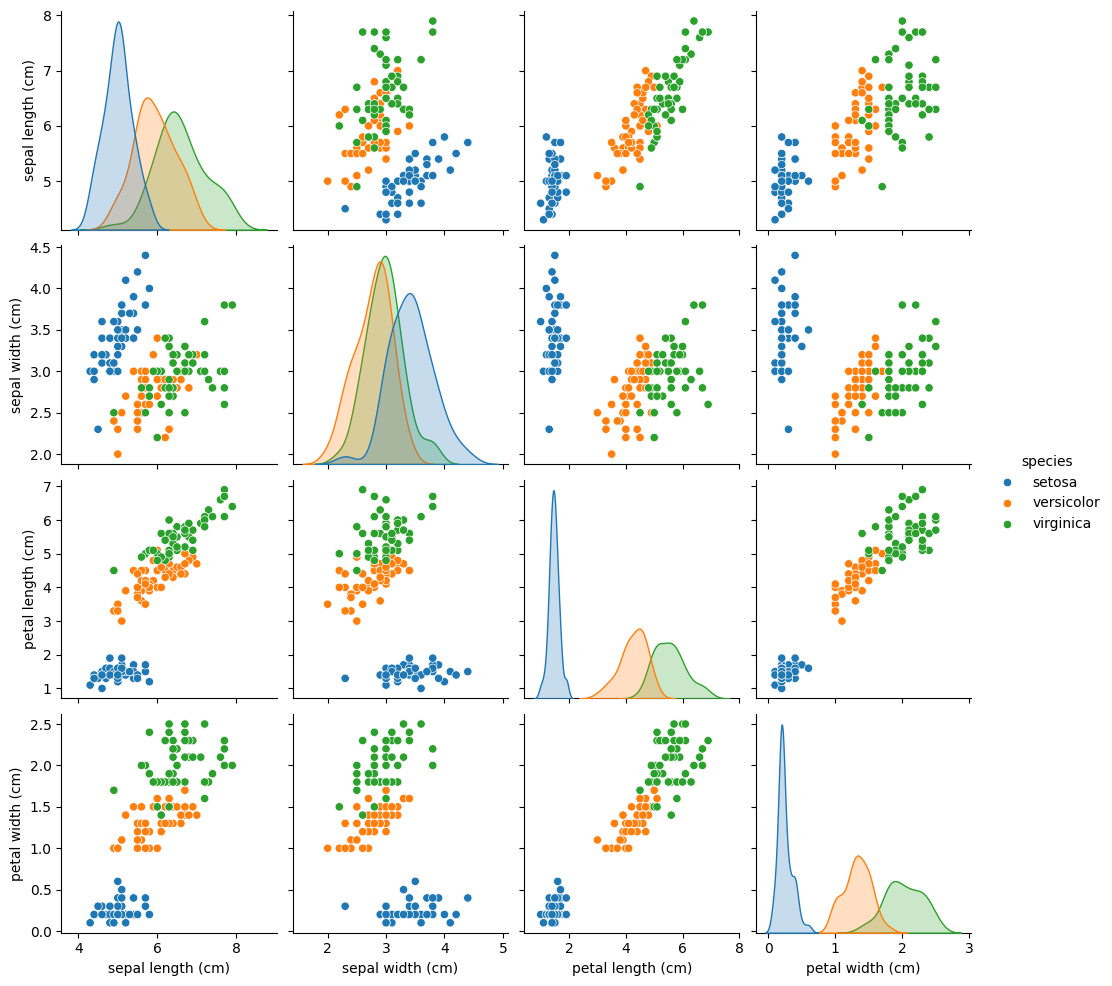

In [3]:
sns.pairplot(df, hue="species")
print("Shape:", df.shape)           # (150 rows, 5 columns)
print("\nSpecies count:")
print(df['species'].value_counts()) # 50 of each species

print("\nBasic statistics:")
df.describe()

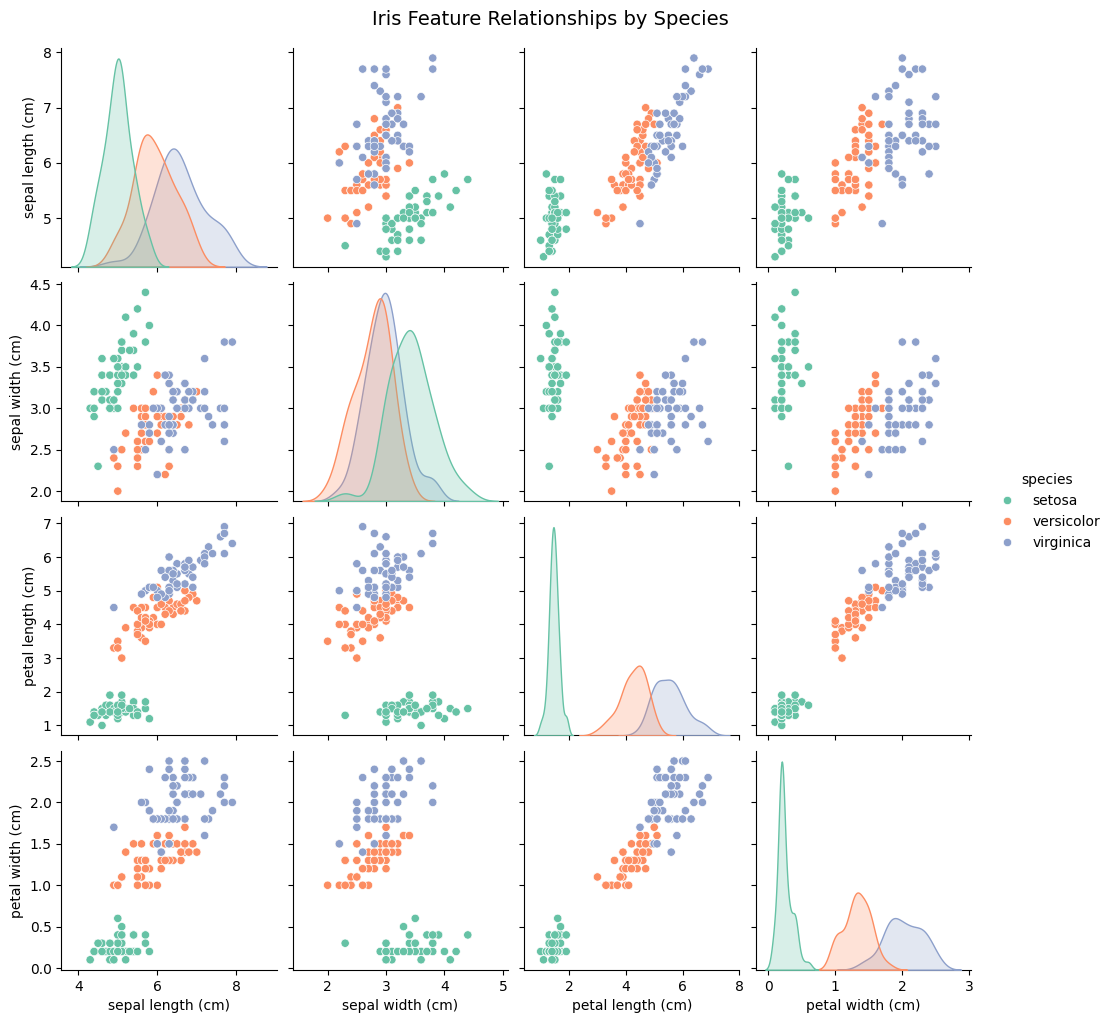

In [4]:
#Pairplot — To see how species cluster together:
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle("Iris Feature Relationships by Species", y=1.02, fontsize=14)
plt.show()

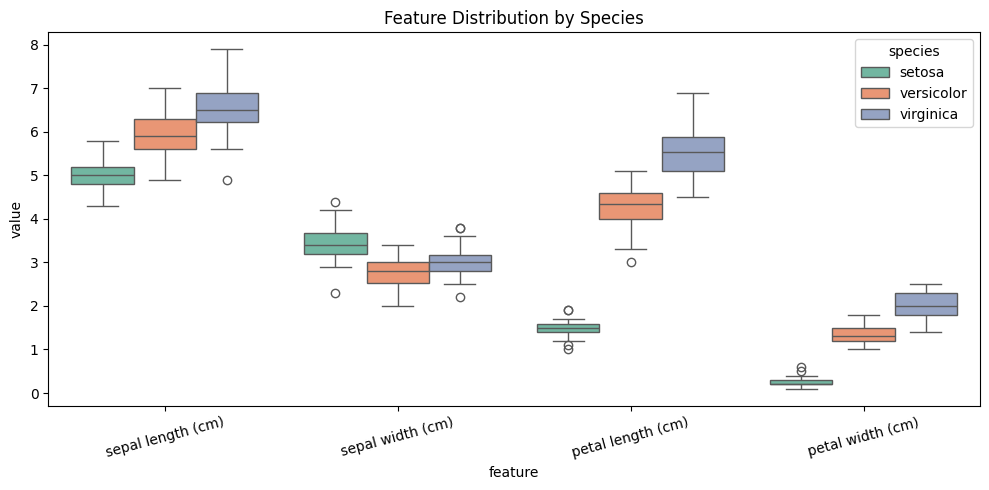

In [5]:
#Box plot — To spot the spread per feature:
df_melted = df.melt(id_vars='species', var_name='feature', value_name='value')
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_melted, x='feature', y='value', hue='species', palette='Set2')
plt.title("Feature Distribution by Species")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Key Observations:

- Setosa species is clearly separable from the other two classes across most features  
- Petal length and petal width show the strongest influence on classification  
- Versicolor and Virginica exhibit some overlap, making them slightly harder to distinguish  
- The dataset is clean with no missing values, making it suitable for model training

## Data Preprocessing

The dataset is split into input features (X) and target variable (y).

We then divide the data into training and testing sets to evaluate the model's performance on unseen data.

In [6]:
#Prepare the Data for Modelling
# X = features (measurements), y = labels (species numbers)
X = iris.data
y = iris.target

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features (makes models more accurate)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit AND transform on training data
X_test  = scaler.transform(X_test)       # ONLY transform on test data (important!)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 120
Testing samples  : 30


## Model Building

In this project, three different machine learning models are used to compare performance:

- Logistic Regression: A linear model used for baseline classification
- Random Forest: An ensemble model that combines multiple decision trees for better accuracy
- Support Vector Machine (SVM): A powerful algorithm that finds the optimal boundary between classes

Using multiple models helps in selecting the most accurate and stable approach for the problem.

In [7]:
# Train & Compare 3 Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                  SVC(kernel='rbf', random_state=42)
}

trained_models = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)          # train
    y_pred = model.predict(X_test)       # predict
    acc = accuracy_score(y_test, y_pred) # evaluate
    results[name] = acc
    trained_models[name] = model
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

Logistic Regression       → Accuracy: 100.00%
Random Forest             → Accuracy: 100.00%
SVM                       → Accuracy: 100.00%


## Model Evaluation

All models achieved 100% accuracy on the test dataset. However, this is expected due to the simplicity and well-structured nature of the Iris dataset.
The performance of each model is evaluated using:

- Accuracy Score
- Classification Report (Precision, Recall, F1-score)
- Confusion Matrix

These metrics help assess how well the model performs and how accurately it predicts each class.

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



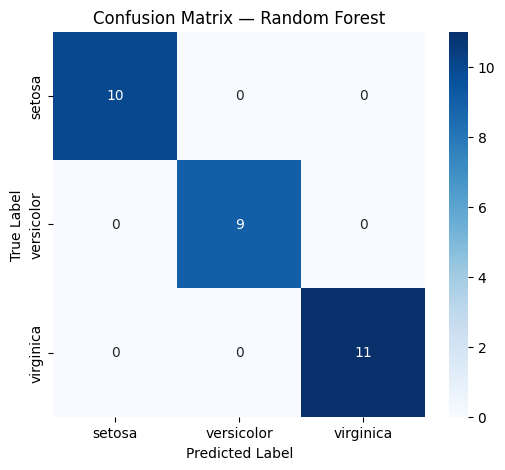

In [8]:
# Deep Evaluation of Best Model
#Use Random Forest (typically best performer)
best_model = trained_models["Random Forest"]
y_pred = best_model.predict(X_test)

# Detailed report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Random Forest")
plt.show()

The confusion matrix shows how well the model distinguishes between each class.

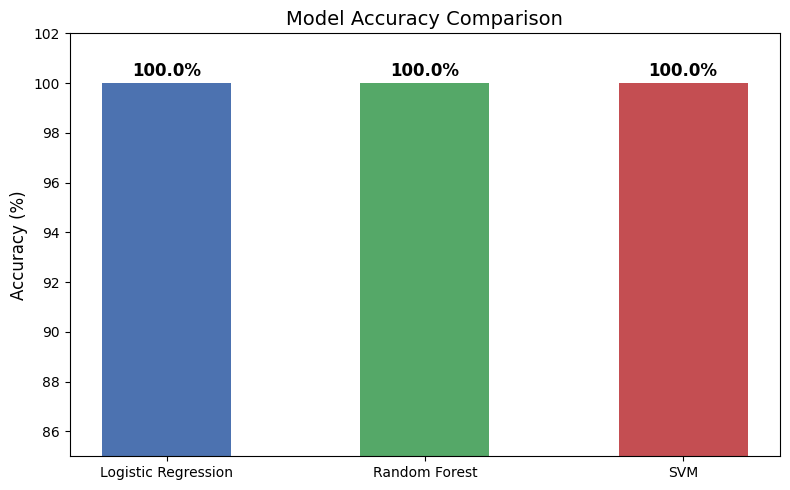

In [9]:
# Model Comparison Chart
plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(results.keys(), [v*100 for v in results.values()], color=colors, width=0.5)

plt.ylim(85, 102)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14)

# Add accuracy labels on top of each bar
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{val*100:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import cross_val_score

print("Cross-Validation Scores (5-fold):\n")
for name, model in models.items():
    # Re-scale using full dataset for CV
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline

    pipeline = make_pipeline(StandardScaler(), model)
    scores = cross_val_score(pipeline, X, y, cv=5)
    print(f"{name:25s} → Mean: {scores.mean()*100:.2f}%  |  Std: ±{scores.std()*100:.2f}%")

Cross-Validation Scores (5-fold):

Logistic Regression       → Mean: 96.00%  |  Std: ±3.89%
Random Forest             → Mean: 96.67%  |  Std: ±2.11%
SVM                       → Mean: 96.67%  |  Std: ±2.11%


## Model Comparison

After evaluating all models:

All three models achieved perfect accuracy on the test dataset, which indicates that the Iris dataset is relatively simple and well-structured.

To obtain a more reliable evaluation, cross-validation was performed.

- Random Forest and SVM achieved the highest mean accuracy (96.67%)
- Both models also showed lower standard deviation (±2.11%), indicating more stable performance
- Logistic Regression performed slightly lower with higher variability

Based on these results, Random Forest and SVM are both strong choices for this classification task, offering a good balance between accuracy and stability.

## Conclusion

In this project, multiple machine learning models were applied to classify iris flower species based on their physical measurements.

Although all models achieved 100% accuracy on the test data, cross-validation revealed more realistic performance differences.

Random Forest and SVM demonstrated higher accuracy and better stability compared to Logistic Regression.

This project highlights the importance of:
- Understanding the dataset through EDA
- Comparing multiple models
- Using cross-validation for reliable evaluation

Overall, the project successfully demonstrates a complete machine learning workflow from data exploration to model evaluation.